# Does the germline residue at an IGHV site associate with the CDR-H3?

**Companion to `cdr3_dependence_of_selection.ipynb`.** That notebook holds the germline
residue fixed and asks whether the *selection factor* moves with the CDR-H3. This notebook
asks the prior question -- is the germline residue associated with the CDR-H3 at all? An association would mean the two germline backgrounds
compared in the entrenchment analysis are not drawn from the same CDR-H3 distribution, so
"the same site on two different backgrounds" involves a different CDR-H3 context as well
as a different residue.

**The answer is that the question cannot be asked of this data**, and the notebook exists
to show why with numbers rather than by assertion. The association is real and nearly
everywhere, but it is explained by `k`, the number of germline amino acids at the site,
and not by CDR-H3 contact or by entrenchment. Contacting sites carry `k = 4` against 2
elsewhere and entrenched sites `k = 6` against 2, so the contrast we want to draw and the
nuisance we have to remove are the same variable.

That is the linkage problem in numerical form. The germline residue is fixed once the V
allele is known, so a site with `k` residues is a `k`-way coarsening of V-gene identity
and nothing more, and a finer coarsening captures more of the real -- but not
site-specific -- V-gene-to-CDR-H3 association. No bias correction removes that, because
statistically it *is* association.

**The selection statistic is not subject to this**, which is why that result stands while
this one cannot: `k` is literally the number of rows of the association table here, and it
does not enter `|delta|` at all, where each unit is one substitution from one germline
residue split at its own pool median. The corresponding tests on the selection data live
in `cdr3_dependence_of_selection.ipynb`.

## Design

Following `cdr3_dependence_of_selection.ipynb`: the descriptor is **split in two at the
median** of the families entering each table; contact is binary at
`cu.CDR3_CONTACT_THRESHOLD`; the unit is a **(site, V family)** pair with IGHV1 and IGHV3
kept separate. One `k x 2` contingency table per site.

## 1. Load and prepare

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr
from statsmodels.regression.linear_model import OLS

import cdr3_stratification_util as cu
from utils import ENTRENCHED_SITE_COLORS, load_and_process_dasm_data

MODEL_NAME = "dasm_4m-v1jaffeCC+v1tangCC-joint"
DATASET_NAME = "v1rodriguez"
NUMBERING = "chothia"
V_FAMILIES = ["IGHV1", "IGHV3"]
MIN_FAMILIES = 60          # matches cdr3_dependence_of_selection.ipynb
MIN_PER_CELL = 5           # a germline residue needs this many families to be a row
CONTACT_THRESHOLD = cu.CDR3_CONTACT_THRESHOLD
N_PERM = 20000

OUTPUT_DIR = f"_output/cdr3_pairing_bias/{NUMBERING}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
sns.set_style("whitegrid")
BLUE, GREY = "#2a78d6", "#9e9d99"
LAB = {"cdr3_length": "CDR-H3 length", "cdr3_charge": "CDR-H3 net charge",
       "cdr3_hydrophobicity": "CDR-H3 hydrophobicity"}
rng = np.random.default_rng(0)

In [2]:
# One row per clonal family. The family is the unit: all PCPs in a family share one
# CDR-H3 and one germline background, so pairs would count the same observation twice.
_, pcp_df, _ = load_and_process_dasm_data(
    model_name=MODEL_NAME, dataset_name=DATASET_NAME,
    numbering_scheme=NUMBERING, figures_dir="figures",
)
pcp_df = cu.add_cdr3_descriptors(pcp_df[pcp_df.depth == 2])
print(f"{pcp_df.cdr3_aa.isna().sum()} of {len(pcp_df)} depth-2 pairs have an invalid "
      f"CDR-H3 span")

families = (
    pcp_df.dropna(subset=["cdr3_aa"])
    .groupby(["sample_id", "family"])
    .agg({"v_gene": "first", "v_family": "first",
          **{d: "first" for d in cu.CDR3_DESCRIPTORS}})
    .reset_index()
)
families = families[families.v_family.isin(V_FAMILIES)]

# Germline AA per site. It is deterministic given the V gene -- that determinism is the
# linkage this notebook is about, and k is how it shows up in the statistic.
germline_codons = pd.read_csv(f"germline/germline_codons_{NUMBERING}.csv",
                              dtype={"site": str})
germline_wide = germline_codons.pivot_table(
    index="v_gene", columns="site", values="amino_acid", aggfunc="first")
germline_wide.columns = [f"germ_{s}" for s in germline_wide.columns]
families = families.merge(germline_wide.reset_index(), on="v_gene", how="left")

# 95-102 is the CDR-H3 itself and 103+ is J-encoded, so only the V region is testable.
sites_all = [s for s in sorted((c.removeprefix("germ_") for c in families.columns
                                if c.startswith("germ_")), key=cu.site_number)
             if cu.site_number(s) <= cu.MAX_V_REGION_SITE]

print(f"{len(families):,} clonal families, {len(sites_all)} V-region sites")
print(families.groupby("v_family").agg(families=("family", "size"),
                                       v_genes=("v_gene", "nunique")).to_string())

Adding one_mutation_away column (vectorized)...


2 of 12942 depth-2 pairs have an invalid CDR-H3 span
5,069 clonal families, 102 V-region sites
          families  v_genes
v_family                   
IGHV1         1583       25
IGHV3         3486       52


In [3]:
# Entrenchment calls and CDR-H3 contact, keyed as the selection notebook keys them.
# Contact frequency comes from each V family's own structures.
contact_by_family = {vf: cu.classify_sites(cu.cdr3_burial_by_site(v_families=(vf,)),
                                           NUMBERING).cdr3_contact_freq
                     for vf in V_FAMILIES}

comp = pd.concat(
    [pd.read_csv(f, dtype={"site": str})
     for f in sorted(glob.glob(
         f"_output/entrenchment_analysis/{NUMBERING}/comparison_within_*.csv"))],
    ignore_index=True)
comp["v_family"] = comp.v_family_1
comp = comp[comp.v_family.isin(V_FAMILIES)
            & (comp.site.map(cu.site_number) <= cu.MAX_V_REGION_SITE)]

# is_entrenched is already per (V family, site, residue pair), so a pair called only in
# IGHV3 is not labelled entrenched in IGHV1 -- the WITHIN_PAIRS_BY_FAMILY convention.
ENT_BY_FAMILY = {vf: set(g.loc[g.is_entrenched, "site"])
                 for vf, g in comp.groupby("v_family")}
ENT_SITES = sorted(set().union(*ENT_BY_FAMILY.values()), key=cu.site_number)
for vf, s in ENT_BY_FAMILY.items():
    print(f"{vf}: entrenched sites {sorted(s, key=cu.site_number)}")

IGHV1: entrenched sites ['33', '50', '52']
IGHV3: entrenched sites ['33', '35', '50', '52', '53']


## 2. One contingency table per site

Rows are the germline amino acids carried by at least `MIN_PER_CELL` families, columns are
the two halves of the CDR-H3 descriptor split at the median of those families. Two
statistics:

- **Cramer's V.** With a binary split `min(k, 2) - 1 = 1`, so `V = sqrt(chi2 / n)`.
- **Bergsma (2013) bias-corrected V**, which subtracts the positive null expectation that
  grows with `k`.

Carrying both is the point: section 3 shows the correction barely moves the `k`
dependence, because most of that dependence is not bias.

**What this checks.** How strongly the germline identity at a site predicts the CDR-H3,
and how the two contrasts of interest look before anything is controlled for.

In [4]:
def site_statistics(fams, site, descriptor):
    # k x 2 association at one site: germline residue vs high/low CDR-H3 descriptor.
    germ_col = f"germ_{site}"
    if germ_col not in fams.columns:
        return None
    d = fams[[germ_col, descriptor]].dropna()
    counts = d[germ_col].value_counts()
    d = d[d[germ_col].isin(counts[counts >= MIN_PER_CELL].index)]
    k, n = d[germ_col].nunique(), len(d)
    if k < 2 or n < MIN_FAMILIES:
        return None

    obs = pd.crosstab(d[germ_col], d[descriptor] > d[descriptor].median()).values
    if obs.shape[1] < 2:
        # Every family fell on one side of the median: the descriptor is constant here so
        # no association is measurable. Returning 0 would be indistinguishable from a
        # measured null, so drop the site instead.
        return None
    exp = np.outer(obs.sum(1), obs.sum(0)) / n
    chi2 = float(((obs - exp) ** 2 / exp).sum())
    phi2 = max(0.0, chi2 / n - (k - 1) / (n - 1))
    k_t = k - (k - 1) ** 2 / (n - 1)
    m_t = 2 - 1 / (n - 1)
    return {"site": site, "k": k, "n_families": n,
            "cramers_v": np.sqrt(chi2 / n),                  # min(k, 2) - 1 == 1
            "v_corrected": np.sqrt(phi2 / (min(k_t, m_t) - 1))}


rows = []
for desc in cu.CDR3_DESCRIPTORS:
    for vf in V_FAMILIES:
        fams_vf = families[families.v_family == vf]
        for site in sites_all:
            r = site_statistics(fams_vf, site, desc)
            if r is None:
                continue
            rows.append({**r, "v_family": vf, "descriptor": desc,
                         "entrenched": site in ENT_BY_FAMILY.get(vf, set()),
                         "contact": float(contact_by_family[vf].get(site, 0.0))})
sites_df = pd.DataFrame(rows)
sites_df["c"] = sites_df.contact > CONTACT_THRESHOLD
sites_df.to_csv(f"{OUTPUT_DIR}/site_table.csv", index=False)
print(f"{len(sites_df) // len(cu.CDR3_DESCRIPTORS)} (site, V family) units per descriptor")


def contrast(d, flag, stat):
    a, b = d[d[flag]], d[~d[flag]]
    return {"n_a": len(a), "n_b": len(b), "stat_a": a[stat].median(),
            "stat_b": b[stat].median(), "ratio": a[stat].median() / b[stat].median(),
            "mannwhitney_p": mannwhitneyu(a[stat], b[stat], alternative="greater").pvalue}


raw = pd.DataFrame([
    {"descriptor": desc, "contrast": name, "statistic": stat,
     **contrast(sites_df[sites_df.descriptor == desc], flag, stat)}
    for desc in cu.CDR3_DESCRIPTORS
    for flag, name in [("c", "contacting vs rest"), ("entrenched", "entrenched vs rest")]
    for stat in ["cramers_v", "v_corrected"]])
raw.to_csv(f"{OUTPUT_DIR}/raw_contrasts.csv", index=False)
print("\nraw contrasts -- both look strong, and section 3 shows both are k:")
print(raw.round(5).to_string(index=False))

94 (site, V family) units per descriptor

raw contrasts -- both look strong, and section 3 shows both are k:
         descriptor           contrast   statistic  n_a  n_b  stat_a  stat_b   ratio  mannwhitney_p
        cdr3_length contacting vs rest   cramers_v   17   77 0.07961 0.04913 1.62050        0.07297
        cdr3_length contacting vs rest v_corrected   17   77 0.07205 0.04077 1.76711        0.12144
        cdr3_length entrenched vs rest   cramers_v    8   86 0.14758 0.04797 3.07663        0.00034
        cdr3_length entrenched vs rest v_corrected    8   86 0.13879 0.03998 3.47172        0.00047
        cdr3_charge contacting vs rest   cramers_v   17   77 0.09326 0.02964 3.14678        0.00070
        cdr3_charge contacting vs rest v_corrected   17   77 0.08004 0.01876 4.26660        0.00084
        cdr3_charge entrenched vs rest   cramers_v    8   86 0.08276 0.03694 2.24074        0.02209
        cdr3_charge entrenched vs rest v_corrected    8   86 0.07063 0.02623 2.69263       

## 3. k explains both contrasts

`k` drives the statistic for two separate reasons, and only the first is removable.

**Mechanical.** Under the null `E[V] > 0` and grows with `k`. Bergsma's correction removes
this.

**Substantive.** With `k` residues the site partitions the V genes into `k` groups, and a
finer partition captures more of whatever V-gene-level CDR-H3 bias exists. No correction
removes this, because statistically it is genuine association -- it simply cannot be
attributed to the site, because linkage means the site label is only a coarsening of
V-gene identity.

The residual `rho(k, V_corrected)` is how much of the second kind is left.

**What this checks.** How much of the association is `k`, and whether contact or
entrenchment adds anything once `k` is in the model.

In [5]:
print("rho(k, statistic) -- correction removes the mechanical part only:\n")
for desc in cu.CDR3_DESCRIPTORS:
    d = sites_df[sites_df.descriptor == desc]
    print(f"  {desc:20s} Cramer's V: {spearmanr(d.k, d.cramers_v)[0]:+.2f}   "
          f"bias-corrected: {spearmanr(d.k, d.v_corrected)[0]:+.2f}")

d = sites_df[sites_df.descriptor == "cdr3_length"]
print(f"\nk by class:  contacting {d[d.c].k.median():.1f} vs rest {d[~d.c].k.median():.1f}"
      f"   |   entrenched {d[d.entrenched].k.median():.1f} vs rest "
      f"{d[~d.entrenched].k.median():.1f}")
print("-> the contrast we want and the nuisance we must remove are the same variable.")


def rank_ols(d, cols, label, y="v_corrected"):
    X = pd.DataFrame({c: (d[c].rank() if c == "k" else d[c].astype(float)) for c in cols})
    X = (X - X.mean()) / X.std(ddof=0)
    X.insert(0, "const", 1.0)
    m = OLS(np.asarray(d[y].rank(), float), np.asarray(X, float)).fit()
    terms = "   ".join(f"{n}: b={b:+.1f} p={p:.3f}"
                       for n, b, p in zip(X.columns, m.params, m.pvalues) if n != "const")
    print(f"  {label:28s} R2={m.rsquared:.3f}   {terms}")


for desc in cu.CDR3_DESCRIPTORS:
    d = sites_df[sites_df.descriptor == desc]
    print(f"\n=== {LAB[desc]}: rank regressions on bias-corrected V ===")
    rank_ols(d, ["c"], "~ contact")
    rank_ols(d, ["entrenched"], "~ entrenched")
    rank_ols(d, ["k"], "~ k")
    rank_ols(d, ["k", "c"], "~ k + contact")
    rank_ols(d, ["k", "entrenched"], "~ k + entrenched")

rho(k, statistic) -- correction removes the mechanical part only:

  cdr3_length          Cramer's V: +0.58   bias-corrected: +0.54
  cdr3_charge          Cramer's V: +0.55   bias-corrected: +0.44
  cdr3_hydrophobicity  Cramer's V: +0.49   bias-corrected: +0.37

k by class:  contacting 4.0 vs rest 2.0   |   entrenched 6.0 vs rest 2.0
-> the contrast we want and the nuisance we must remove are the same variable.

=== CDR-H3 length: rank regressions on bias-corrected V ===
  ~ contact                    R2=0.015   c: b=+3.3 p=0.243
  ~ entrenched                 R2=0.118   entrenched: b=+9.3 p=0.001
  ~ k                          R2=0.293   k: b=+14.6 p=0.000
  ~ k + contact                R2=0.302   k: b=+15.7 p=0.000   c: b=-2.8 p=0.274
  ~ k + entrenched             R2=0.304   k: b=+13.1 p=0.000   entrenched: b=+3.1 p=0.245

=== CDR-H3 net charge: rank regressions on bias-corrected V ===
  ~ contact                    R2=0.106   c: b=+8.7 p=0.001
  ~ entrenched                 R2=0.03

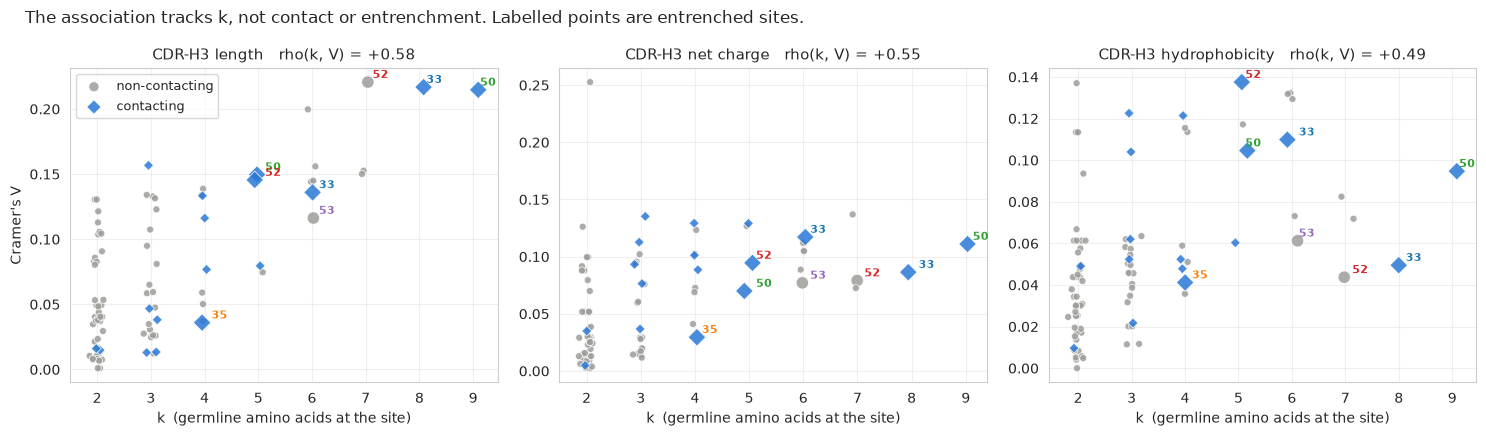

In [6]:
# The whole argument in one picture: the trend runs along k, and within any column of the
# plot contacting and non-contacting sites overlap.
fig, axes = plt.subplots(1, len(cu.CDR3_DESCRIPTORS), figsize=(15, 4.4))
jit = np.random.default_rng(0)
for ax, desc in zip(axes, cu.CDR3_DESCRIPTORS):
    d = sites_df[sites_df.descriptor == desc]
    for lab, m, mk in [("non-contacting", ~d.c, "o"), ("contacting", d.c, "D")]:
        g = d[m]
        ax.scatter(g.k + jit.normal(0, 0.06, len(g)), g.cramers_v,
                   s=np.where(g.entrenched, 80, 26),
                   c=[BLUE if x else GREY for x in g.c], marker=mk,
                   edgecolor="white", linewidth=0.6, alpha=0.85, label=lab)
    for r in d[d.entrenched].itertuples():
        ax.annotate(r.site, (r.k, r.cramers_v), xytext=(5, 3),
                    textcoords="offset points", fontsize=8, fontweight="bold",
                    color=ENTRENCHED_SITE_COLORS.get(r.site, "#333"))
    ax.set_title(f"{LAB[desc]}   rho(k, V) = {spearmanr(d.k, d.cramers_v)[0]:+.2f}",
                 fontsize=10.5)
    ax.set_xlabel("k  (germline amino acids at the site)", fontsize=10)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Cramer's V", fontsize=10)
axes[0].legend(fontsize=9)
fig.suptitle("The association tracks k, not contact or entrenchment. "
             "Labelled points are entrenched sites.", fontsize=12.5, x=0.02, ha="left")
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig_statistic_vs_k.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 4. The test: permute the label within strata of equal k

One inferential test. Shuffling contact (or entrenchment) **within `k` strata** holds `k`
exactly fixed, which a regression adjustment only does on average. Strata containing a
single class are dropped, since permutation there is a no-op.

The null mean is not zero: the groups are very unequal in size and the statistic is a
difference of medians of a right-skewed quantity, so a positive gap is expected under the
null. The p-value accounts for that; the raw gap does not.

**What this checks.** Whether CDR-H3 contact, or entrenchment, predicts the association at
all once `k` is held fixed.

In [7]:
def stratified_perm(d, flag, stat="v_corrected", n_perm=N_PERM):
    # Permute `flag` within strata of equal k, so k is held exactly fixed.
    both = d.groupby("k")[flag].nunique()
    d = d[d.k.isin(both[both == 2].index)]
    if len(d) < 6 or d[flag].sum() < 2:
        return None
    lab, ks, v = d[flag].to_numpy(), d.k.to_numpy(), d[stat].to_numpy()
    obs = np.median(v[lab]) - np.median(v[~lab])
    null = np.empty(n_perm)
    for i in range(n_perm):
        p = lab.copy()
        for kk in np.unique(ks):
            m = ks == kk
            p[m] = rng.permutation(lab[m])
        null[i] = np.median(v[p]) - np.median(v[~p])
    return {"n": len(d), "n_flagged": int(lab.sum()), "obs_gap": obs,
            "null_mean": float(null.mean()),
            "ratio": np.median(v[lab]) / np.median(v[~lab]),
            "p_perm": float((np.sum(null >= obs) + 1) / (n_perm + 1))}


perm_test = pd.DataFrame([
    {"descriptor": desc, "contrast": name, **r}
    for desc in cu.CDR3_DESCRIPTORS
    for flag, name in [("c", "contacting"), ("entrenched", "entrenched")]
    if (r := stratified_perm(sites_df[sites_df.descriptor == desc], flag)) is not None])
perm_test.to_csv(f"{OUTPUT_DIR}/stratified_permutation_test.csv", index=False)
print("contact / entrenchment permuted WITHIN k strata (bias-corrected V):\n")
print(perm_test.round(5).to_string(index=False))

contact / entrenchment permuted WITHIN k strata (bias-corrected V):

         descriptor   contrast  n  n_flagged  obs_gap  null_mean   ratio  p_perm
        cdr3_length contacting 89         15  0.03266    0.03200 1.85277 0.54417
        cdr3_length entrenched 22          6  0.00392    0.00498 1.03106 0.63647
        cdr3_charge contacting 89         15  0.06297    0.04315 4.69080 0.10509
        cdr3_charge entrenched 22          6 -0.02297    0.00273 0.74541 0.96315
cdr3_hydrophobicity contacting 89         15  0.01568    0.01125 1.45870 0.24009
cdr3_hydrophobicity entrenched 22          6  0.00345    0.01830 1.05185 0.76946


### Caveats

- **`k` may be a mediator rather than a confound.** If CDR-H3 contact is what permits
  germline diversity at these sites, `k` sits on the causal path and conditioning on it
  removes real signal. This data cannot distinguish that from `k` being a pure nuisance.
  We lean to the nuisance reading because the extra association a finer partition buys is
  V-gene-level by construction and linkage says it cannot be attributed to the site -- but
  the honest statement is that `k` and contact are collinear here and no site-specific
  claim is supportable in either direction.
- **Power.** A handful of contacting and entrenched units, and the entrenchment
  permutation uses only the strata containing both classes. A null here is "consistent
  with no enrichment", not "no enrichment exists".
- **This is an association in the repertoire, not selection.** A site can associate
  strongly because its residues sit on V genes with different D or J usage, with no
  interaction between residue and loop.
- **Direction is not reported.** Cramer's V is unsigned and the germline residues have no
  canonical ordering, so unlike the selection notebook there is no sign test to run.